In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('../../'))
from src.analysis.metrics import *
from src.modeling.feature_engineering import check_stationarity, reverse_smoothing, reverse_log

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.holtwinters import Holt

##### **It is assumed that the time series are stationary**

In [2]:
# Restaurant data with the ingredients to predict
daily_consumption_df = pd.read_csv('../../data/restaurant_daily_consumption.csv', index_col=0, parse_dates=True)
#daily_consumption_df = daily_consumption_df[['Sugar', 'Clove']]
display(daily_consumption_df)

output_size = daily_consumption_df.columns.size
target_columns = daily_consumption_df.columns

,Salt,Garlic,Clove,Paprika
Date,,,,
2019-01-01,162.974727,19.849773,0.125728,2.441247
2019-01-02,99.851043,13.459318,0.070579,1.808771
2019-01-03,119.860452,15.462596,0.055736,2.481908
2019-01-04,97.104337,13.284490,0.052449,1.406736
2019-01-05,198.989110,27.495572,0.149708,3.414856
...,...,...,...,...
2019-06-26,114.141431,14.064159,0.061994,2.004435
2019-06-27,213.521591,31.728243,0.129388,3.366290
2019-06-28,186.391889,25.140486,0.114119,2.857067


##### Apply Log Transformation

In [3]:
# Apply log transformation to numerical features
df_log_transformed = daily_consumption_df.copy()
df_log_transformed = np.log1p(daily_consumption_df) # Apply log1p (log(x + 1))
#display(df_log_transformed)

# Check correlation
corr_matrix = df_log_transformed.corr()
display(corr_matrix)

,Salt,Garlic,Clove,Paprika
Salt,1.000000,0.990012,0.903748,0.956647
Garlic,0.990012,1.000000,0.902960,0.950352
Clove,0.903748,0.902960,1.000000,0.892338
Paprika,0.956647,0.950352,0.892338,1.000000


##### Run the ADF test and identify non-stationary series

In [4]:
# List to store the ADF test results and non stationary series
results = []
non_stationary_columns = []

# Apply the check for each ingredient
for col in df_log_transformed.columns:
    adf_statistic, p_value, isStationary = check_stationarity(df_log_transformed[col])
    
    # Create a dictionary for each result
    result_dict = {
        'Ingredient': col,
        'ADF Statistic': adf_statistic,
        'p-value': p_value,
        'isStationary': isStationary,
        'Stationarity Conclusion': "Series is stationary" if isStationary else "Series is not stationary"
    }
    
    # Append the dictionary to the results list
    results.append(result_dict)

    # Store non-stationary columns
    if not isStationary:
        non_stationary_columns.append(col)

# Convert the list of dictionaries to a DataFrame to display ADF results
adf_results = pd.DataFrame(results)
display(adf_results)

,Ingredient,ADF Statistic,p-value,isStationary,Stationarity Conclusion
0,Salt,-2.267326,0.182723,False,Series is not stationary
1,Garlic,-2.236748,0.193179,False,Series is not stationary
2,Clove,-3.419346,0.010317,True,Series is stationary
3,Paprika,-2.407168,0.139723,False,Series is not stationary


##### Making time series stationary

In [5]:
# Set frequency to daily
df_log_transformed = df_log_transformed.asfreq('D')

# Dictionary to store residuals and trends for each ingredient
residuals_dict = {}
trends_dict = {}

# Apply smoothing level to non-stationary series
for col_name in target_columns:
    # Extract the ingredient's time series
    ingredient_series = df_log_transformed[col_name]

    if col_name in non_stationary_columns:
        # Fit the Holt model to the series
        model = Holt(ingredient_series)
        results = model.fit(smoothing_level=0.15)

        # Extract the fitted trend
        trend = results.fittedvalues

        # Calculate the residuals (original - trend)
        residual = ingredient_series - trend
        
        # Store the residuals and trends in their respective dictionaries
        residuals_dict[col_name] = residual
        trends_dict[col_name] = trend
    else: 
        # If the series is stationary, store it directly in the residuals
        residuals_dict[col_name] = ingredient_series

# Combine the residuals and trends into DataFrames
df_stationary_data = pd.DataFrame(residuals_dict)
df_trend_data = pd.DataFrame(trends_dict)

# Display the final DataFrames
# display(df_stationary_data)
# display(df_trend_data)

In [6]:
# Determine the split index for training and testing data - Holdout cross-validation
train_size = int(len(df_stationary_data) * 0.80) 
df_train = df_stationary_data[:train_size]
df_test = df_stationary_data[train_size:]

# Fit the VAR model
model = VAR(df_train)

# Select the best lag feature
select_lag_feature = model.select_order(maxlags=10)
select_lag_feature.summary()

,AIC,BIC,FPE,HQIC
0,-15.13,-15.05,2.674e-07,-15.10
1,-15.63,-15.20*,1.622e-07,-15.46
2,-15.96,-15.18,1.170e-07,-15.65*
3,-16.01,-14.89,1.116e-07,-15.55
4,-16.16,-14.69,9.667e-08,-15.56
5,-16.37*,-14.56,7.823e-08*,-15.64
6,-16.24,-14.08,9.027e-08,-15.36
7,-16.29,-13.79,8.627e-08,-15.27
8,-16.18,-13.32,9.813e-08,-15.02
9,-16.07,-12.87,1.113e-07,-14.77


##### Apply Rolling Cross-Validation

In [7]:
# Rolling Window CV with n folds
n_folds = 3  # You can increase this if needed
tss = TimeSeriesSplit(n_splits=n_folds)
print("Number of folds: ", n_folds)
print("Number of timespteps: ", len(df_stationary_data), "\n")


# For storing the results of each fold
fold_results = []
# For storing RMSE values
fold_rmse_values = []

print("Starting Time Series Cross-Validation... \n")
for fold_idx, (train_index, test_index) in enumerate(tss.split(df_stationary_data)):
    
    # Print the current fold and the training/testing time steps
    print(f"Fold {fold_idx+1}/{n_folds}")

    # Create training and test datasets for the current fold
    df_train = df_stationary_data.iloc[train_index]
    df_test = df_stationary_data.iloc[test_index]

    # Set the frequency explicitly to daily
    df_train = df_train.asfreq('D')
    df_test = df_test.asfreq('D')

    # Print the start and end timesteps for train and test sets
    print(f"Train set timesteps: {train_index[0]+1} to {train_index[-1]+1}")
    print(f"Test set timesteps: {test_index[0]+1} to {test_index[-1]+1}")

    print("Fitting the VAR model...")
    # Fit the VAR model
    var_model = VAR(df_train)
    # Allow the model to choose the optimal lag using AIC
    predicted_results = var_model.fit(ic='aic')
    print(f"Selected lag: {predicted_results.k_ar}")

    print("Start getting the forecasted results for the test set...")
    forecast_steps = len(df_test) 
    # Store predictions
    df_forecasts = pd.DataFrame(index=df_test.index, columns=df_test.columns)
    # Use rolling forecast (recursive forecasting)
    total_history = df_train.values.tolist()  # Initialize the history with the training data
    
    for t in range(forecast_steps):
        # Convert history to a NumPy array before forecasting
        history_array = np.array(total_history)
        # Predict one step ahead
        prediction = predicted_results.forecast(y=history_array, steps=1)
        # Store the prediction
        df_forecasts.iloc[t] = prediction[0]
        # Update history with the actual test value
        total_history.append(df_test.iloc[t].values)

    # Convert all columns to numeric values
    df_forecasts = df_forecasts.apply(pd.to_numeric, errors='coerce')
    #display(df_forecasts)

    # Reverse the transformations
    df_forecast_without_smooth = reverse_smoothing(df_forecasts, trends_dict, forecast_steps)   # Reverse the smoothing for forecasted values
    #display(df_forecast_without_smooth)
    df_test_without_smooth = reverse_smoothing(df_test, trends_dict, forecast_steps)    # Reverse the smoothing for test values
    df_test_forecasts = reverse_log(df_forecast_without_smooth)
    df_test_actuals = reverse_log(df_test_without_smooth)

    # Calculate RMSE for this fold
    #rmse = calculate_rmse(np.array(df_test), np.array(df_forecasts))
    rmse = calculate_rmse(np.array(df_test_actuals), np.array(df_test_forecasts))
    fold_rmse_values.append(rmse)

    # Store the results of this fold
    fold_results.append({
        'fold': fold_idx + 1,
        'test_start_timestep': test_index[0],
        'test_end_timestep': test_index[-1],
        'rmse': rmse,
        'df_forecasts_transf': df_forecasts,
        'df_test_transf': df_test
        #'test_pred': df_test_forecasts,  # denormalized
        #'test_actuals': df_test_actuals,    # denormalized
    })

    print(f"Training completed. RMSE: {rmse}\n")

# Calculate average RMSE across all folds
average_rmse = np.mean(fold_rmse_values)
print(f"Average RMSE across {n_folds} folds: {average_rmse}")

Number of folds:  3
Number of timespteps:  181 

Starting Time Series Cross-Validation... 

Fold 1/3
Train set timesteps: 1 to 46
Test set timesteps: 47 to 91
Fitting the VAR model...
Selected lag: 8
Start getting the forecasted results for the test set...


Training completed. RMSE: 143.20152643710173

Fold 2/3
Train set timesteps: 1 to 91
Test set timesteps: 92 to 136
Fitting the VAR model...
Selected lag: 12
Start getting the forecasted results for the test set...


Training completed. RMSE: 36.04815969818876

Fold 3/3
Train set timesteps: 1 to 136
Test set timesteps: 137 to 181
Fitting the VAR model...
Selected lag: 5
Start getting the forecasted results for the test set...


Training completed. RMSE: 26.09213172267145

Average RMSE across 3 folds: 68.44727261932064


Best fold is Fold 3 with RMSE: 26.09213172267145


Salt RMSE:  90.07878441307649
Salt MAPE:  40.45163621001936
Salt MAE:  67.16070789716078

Garlic RMSE:  12.545475862361526
Garlic MAPE:  40.91110388147973
Garlic MAE:  9.234945387863954

Clove RMSE:  0.06382796169876565
Clove MAPE:  53.89488832965843
Clove MAE:  0.049351594490571214

Paprika RMSE:  1.6804386535490183
Paprika MAPE:  44.79126089268228
Paprika MAE:  1.2208489285701638



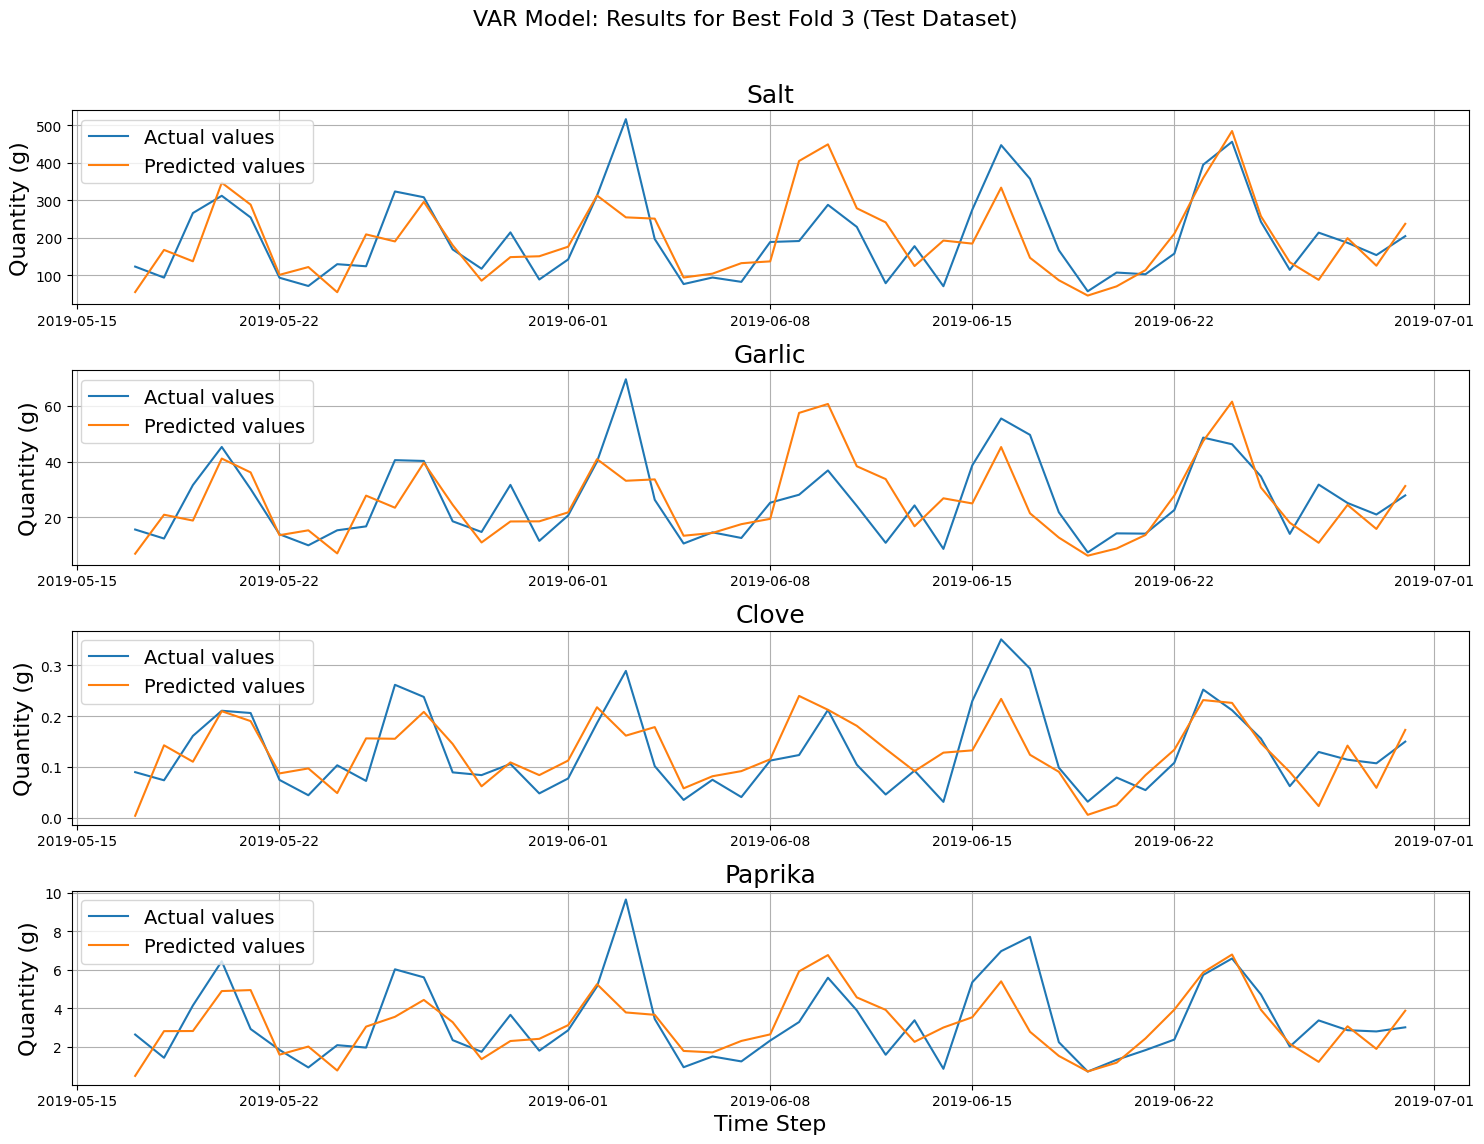

In [8]:
# Find the fold with the best validation loss
best_fold_result = min(fold_results, key=lambda x: x['rmse'])
best_fold_idx = best_fold_result['fold'] - 1  # fold index starts from 0

# Print the fold with the best result
print(f"Best fold is Fold {best_fold_result['fold']} with RMSE: {best_fold_result['rmse']}")

# Start and end timesteps for the best fold
start_timestep = fold_results[best_fold_idx]['test_start_timestep']
end_timestep = fold_results[best_fold_idx]['test_end_timestep']

####*
predicted_df = fold_results[best_fold_idx]['df_forecasts_transf']
df_test_transf = fold_results[best_fold_idx]['df_test_transf']
forecast_steps = len(df_test_transf)
# Reverse the smoothing for forecasted values
df_forecast_without_smooth = reverse_smoothing(predicted_df, trends_dict, forecast_steps)
# Reverse the smoothing for test values
df_test_without_smooth = reverse_smoothing(df_test_transf, trends_dict, forecast_steps)
# Reverse the log transformation
df_test_forecasts = reverse_log(df_forecast_without_smooth)
df_test_actuals = reverse_log(df_test_without_smooth)
####*

# Prepare time steps for the test set of the best fold
time_steps_test = daily_consumption_df.index[start_timestep:end_timestep+1]

# Plotting the predicted vs actual values for each output
fig, axes = plt.subplots(output_size, 1, figsize=(15, 3 * output_size))
fig.suptitle(f'VAR Model: Results for Best Fold {best_fold_result["fold"]} (Test Dataset)', fontsize=16)

for idx, ingredient in enumerate(target_columns):
    # Testing data
    ingr_test_pred = df_test_forecasts.iloc[:, idx]
    ingr_test_actuals = df_test_actuals.iloc[:, idx]

    ingr_rmse = calculate_rmse(ingr_test_actuals, ingr_test_pred)
    print(f'{ingredient} RMSE: ', ingr_rmse)
    ingr_MAPE = calculate_mape(ingr_test_actuals, ingr_test_pred)
    print(f'{ingredient} MAPE: ', ingr_MAPE)
    ingr_mae = calculate_mae(ingr_test_actuals, ingr_test_pred)  # Calculate MAE
    print(f'{ingredient} MAE: ', ingr_mae)  # Print MAE

    print()

    # Plot the results
    ax = axes[idx]
    ax.plot(time_steps_test, ingr_test_actuals, label='Actual values')
    ax.plot(time_steps_test, ingr_test_pred, label='Predicted values')
    ax.set_title(f'{ingredient}', fontsize=18)  # Increase title font size for each subplot

    # Set x-axis label only for the last subplot
    if idx == output_size - 1:
        ax.set_xlabel('Time Step', fontsize=16)  # Increase x-axis label font size

    ax.set_ylabel('Quantity (g)', fontsize=16)  # Increase y-axis label font size
    ax.legend(fontsize=14)  # Increase legend font size
    ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])  # Adjust layout to make space for the suptitle
plt.show()


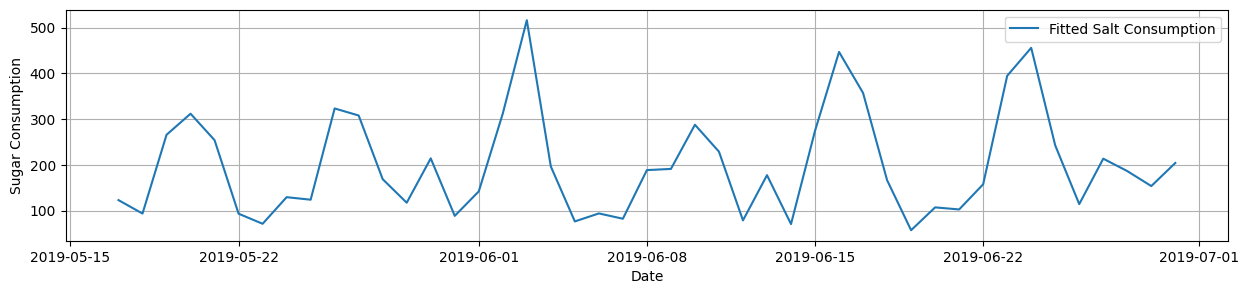

In [9]:
df_salt = daily_consumption_df[['Salt']]
plt.figure(figsize=(15, 3))
plt.plot(time_steps_test, df_salt[start_timestep:end_timestep+1], label='Fitted Salt Consumption')
plt.xlabel('Date')
plt.ylabel('Sugar Consumption')
plt.legend()
plt.grid(True)
plt.show()